# Sliced Wasserstein Projections

This notebook generates `fig:sliced-wasserstein-projections`.  Sliced Wasserstein replaces a high-dimensional comparison by many one-dimensional projected comparisons,
$$
    \operatorname{SW}_p(\alpha,\beta)^p
    =\int_{\mathbb S^{d-1}} W_p((P_\theta)_\#\alpha,(P_\theta)_\#\beta)^p\,d\theta .
$$
The planar densities below are smoothed from deterministic farthest-point samples of silhouettes, and the projected one-dimensional panels use smoothed density estimates rather than transport solves.

In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

ROOT = Path.cwd()
if (ROOT / "notebooks-figures" / "figure_style.py").exists():
    FIGROOT = ROOT / "notebooks-figures"
elif (ROOT / "figure_style.py").exists():
    FIGROOT = ROOT
    ROOT = FIGROOT.parent
elif (ROOT.parent / "notebooks-figures" / "figure_style.py").exists():
    ROOT = ROOT.parent
    FIGROOT = ROOT / "notebooks-figures"
else:
    raise RuntimeError("Could not locate notebooks-figures/figure_style.py")

sys.path.insert(0, str(FIGROOT))

import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter, gaussian_filter1d

from figure_style import (
    BLUE,
    RED,
    VIOLET,
    ORANGE,
    GRAY,
    LIGHT_GRAY,
    DIRAC_MARKER_SIZE,
    box_axes,
    draw_point_clouds,
    draw_transport_segments,
    figure_dir,
    interp_color,
    padded_limits,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

from PIL import Image

NAME = "sliced-wasserstein-projections"
out = figure_dir(NAME)
rng = np.random.default_rng(12)
assets = FIGROOT / "assets"

We extract foreground pixels, reduce them to a dense candidate set, and then apply farthest-point sampling.  The displayed planar panels are not point clouds: they are smoothed kernel-density-style grayscale images.  The middle panels show the same idea after projection, using one-dimensional smoothed densities rather than histograms.

In [2]:
def foreground_pixels(path, *, max_candidates=26000):
    img = Image.open(path).convert("RGBA")
    arr = np.asarray(img)
    gray = np.asarray(img.convert("L"), dtype=float)
    alpha = arr[..., 3].astype(float)
    if alpha.max() - alpha.min() > 100 and alpha.min() < 80:
        mask = alpha > 80
    else:
        mask = gray < 238
    yy, xx = np.nonzero(mask)
    pts = np.column_stack([xx, -yy]).astype(float)
    pts -= pts.mean(axis=0, keepdims=True)
    pts /= max(np.linalg.norm(pts, axis=1).max(), 1e-12)
    if len(pts) > max_candidates:
        idx = rng.choice(len(pts), size=max_candidates, replace=False)
        pts = pts[idx]
    return pts


def farthest_point_sample(points, n, *, seed=0):
    local_rng = np.random.default_rng(seed)
    pts = np.asarray(points, dtype=float)
    idx = np.empty(n, dtype=int)
    center = pts.mean(axis=0)
    idx[0] = int(np.argmin(np.sum((pts - center) ** 2, axis=1)))
    dist2 = np.sum((pts - pts[idx[0]]) ** 2, axis=1)
    for k in range(1, n):
        idx[k] = int(np.argmax(dist2))
        dist2 = np.minimum(dist2, np.sum((pts - pts[idx[k]]) ** 2, axis=1))
    sampled = pts[idx]
    # A tiny deterministic jitter avoids visually perfect lattice artifacts.
    nn = np.sqrt(np.partition(((sampled[:, None, :] - sampled[None, :, :]) ** 2).sum(axis=2), 1, axis=1)[:, 1])
    sampled = sampled + 0.045 * np.median(nn) * local_rng.normal(size=sampled.shape)
    return sampled


n = 3000
alpha_pts = farthest_point_sample(foreground_pixels(assets / "cat.png"), n, seed=13)
beta_pts = farthest_point_sample(foreground_pixels(assets / "heart.jpg"), n, seed=17)
alpha_pts = alpha_pts @ np.array([[0.96, -0.06], [0.06, 0.96]]).T
beta_pts = beta_pts @ np.array([[0.92, 0.10], [-0.10, 0.92]]).T

angles = np.deg2rad([-65, -32, 0, 34, 68])
directions = np.column_stack([np.cos(angles), np.sin(angles)])
dir_colors = [RED, ORANGE, VIOLET, BLUE, "#1a9850"]
dir_styles = ["-", "-", "-", "-", "-"]
LIM = 1.08


The exported PDFs contain no embedded titles.  LaTeX supplies the panel names below each subfigure.

In [3]:
def kde2d_image(points, *, bins=205, sigma=3.2, lim=LIM):
    H, xedges, yedges = np.histogram2d(
        points[:, 0],
        points[:, 1],
        bins=bins,
        range=[[-lim, lim], [-lim, lim]],
        density=True,
    )
    Z = gaussian_filter(H.T, sigma=sigma, mode="nearest")
    Z = Z / max(float(Z.max()), 1e-15)
    return Z, (xedges[0], xedges[-1], yedges[0], yedges[-1])


def draw_density(points, filename):
    fig, ax = plt.subplots(figsize=(2.12, 2.12))
    Z, extent = kde2d_image(points)
    ax.imshow(
        Z ** 0.62,
        cmap="Greys",
        origin="lower",
        extent=extent,
        interpolation="bilinear",
        vmin=0,
        vmax=1,
        zorder=1,
    )
    for theta, color, style in zip(directions, dir_colors, dir_styles):
        line = np.vstack([-0.98 * theta, 0.98 * theta])
        ax.plot(line[:, 0], line[:, 1], color=color, lw=0.82, ls=style, alpha=0.74, zorder=3)
    ax.set_aspect("equal")
    ax.set_xlim(-LIM, LIM)
    ax.set_ylim(-LIM, LIM)
    remove_axes(ax)
    save_pdf(fig, out / filename, pad_inches=0.026)
    plt.close(fig)


def smooth_projected_density(points, theta, bins):
    proj = points @ theta
    h, _ = np.histogram(proj, bins=bins, density=True)
    h = gaussian_filter1d(h, sigma=2.1, mode="nearest")
    return h / max(float(h.max()), 1e-15)


def draw_density_stack(points, filename):
    fig, ax = plt.subplots(figsize=(1.60, 2.12))
    bins = np.linspace(-LIM, LIM, 96)
    centers = 0.5 * (bins[:-1] + bins[1:])
    for k, (theta, color, style) in enumerate(zip(directions, dir_colors, dir_styles)):
        h = smooth_projected_density(points, theta, bins)
        base = len(directions) - 1 - k
        ax.fill_between(centers, base, base + 0.62 * h, color=color, alpha=0.13, linewidth=0)
        ax.plot(centers, base + 0.62 * h, color=color, lw=0.90, alpha=0.95)
        ax.plot([bins[0], bins[-1]], [base, base], color=color, lw=0.76, ls=style, alpha=0.86)
    ax.set_xlim(bins[0], bins[-1])
    ax.set_ylim(-0.17, len(directions) - 0.17)
    remove_axes(ax)
    save_pdf(fig, out / filename, pad_inches=0.026)
    plt.close(fig)


draw_density(alpha_pts, "density-alpha.pdf")
draw_density_stack(alpha_pts, "hist-alpha.pdf")
draw_density_stack(beta_pts, "hist-beta.pdf")
draw_density(beta_pts, "density-beta.pdf")


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


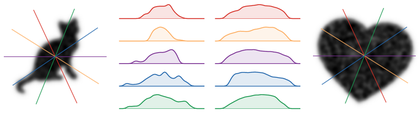

In [4]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/sliced-wasserstein-projections.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/sliced-wasserstein-projections.png")
display(Image(filename=str(_thumb)))
